<a href="https://colab.research.google.com/github/digiblackdranzer/HSAlgorithm/blob/master/AMRP_Loan_Dataset_Result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Import libraries needed for model creation and data processing

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

### Loading the data and understanding how data looks

In [ ]:
# Reload skipping the first 2 rows, row 2 becomes the header
df = pd.read_excel('/content/Book3_dataset_amrp.xlsx', header=2)

# Drop the unnamed row-number column
df = df.drop(columns=df.columns[0])

# Clean up column names - extract just the short name before \n
df.columns = [col.split('\n')[0] if '\n' in str(col) else col for col in df.columns]

# Preview
df.head(10)

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,dti,fico_range_low,loan_status
0,10000,36,20.45,373.93,E,10,65223.56,34.63,612,0
1,5000,36,13.38,169.39,C,6,151033.43,18.61,673,0
2,15000,60,16.94,372.30,D,9,39977.63,12.69,649,0
3,40000,36,6.61,1227.96,A,9,68580.63,30.40,755,0
4,7500,36,11.79,248.36,B,9,88977.05,40.05,731,0
5,20000,60,17.42,501.58,D,3,164469.08,44.89,641,0
6,30000,36,14.03,1025.77,C,10,108425.38,33.83,694,0
7,40000,60,19.17,1041.37,D,10,44174.45,25.31,664,0
8,5000,36,12.01,166.10,B,9,74742.15,42.88,704,0
9,12000,60,17.98,304.59,D,6,109973.01,44.81,643,1


In [ ]:
# 1. Shape - rows and columns
print("Shape:", df.shape)

# 2. First few rows
print("\nFirst 5 rows:")
df.head()

# 3. Column names and data types
print("Columns & dtypes:")
print(df.dtypes)

# 4. Basic statistics (numeric columns)
print("\nSummary statistics:")
df.describe()

# 5. Missing values
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# 6. Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# 7. Unique values per column (useful for categorical columns)
print("\nUnique values per column:")
for col in df.columns:
    print(f"  {col}: {df[col].nunique()} unique values")

# 8. Quick info summary (dtypes + non-null counts)
df.info()

Shape: (200, 10)

First 5 rows:
Columns & dtypes:
loan_amnt           int64
term                int64
int_rate          float64
installment       float64
grade              object
emp_length          int64
annual_inc        float64
dti               float64
fico_range_low      int64
loan_status         int64
dtype: object

Summary statistics:

Missing values per column:
loan_amnt         0
term              0
int_rate          0
installment       0
grade             0
emp_length        0
annual_inc        0
dti               0
fico_range_low    0
loan_status       0
dtype: int64

Total missing: 0

Duplicate rows: 0

Unique values per column:
  loan_amnt: 11 unique values
  term: 2 unique values
  int_rate: 192 unique values
  installment: 199 unique values
  grade: 7 unique values
  emp_length: 11 unique values
  annual_inc: 200 unique values
  dti: 192 unique values
  fico_range_low: 129 unique values
  loan_status: 2 unique values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200

There are no missing values but we need to handle category variable grade

### Handling Category variable

In [ ]:
grade_order = {'A': 5, 'B': 4, 'C': 3, 'D': 2, 'E': 1}
df['grade'] = df['grade'].map(grade_order)

df.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,annual_inc,dti,fico_range_low,loan_status
0,10000,36,20.45,373.93,1.0,10,65223.56,34.63,612,0
1,5000,36,13.38,169.39,3.0,6,151033.43,18.61,673,0
2,15000,60,16.94,372.30,2.0,9,39977.63,12.69,649,0
3,40000,36,6.61,1227.96,5.0,9,68580.63,30.40,755,0
4,7500,36,11.79,248.36,4.0,9,88977.05,40.05,731,0


### Clean up Null values

In [ ]:
print(df.isnull().sum())  # Check which columns have NaN now
df = df.dropna()
print(df.shape)

loan_amnt         0
term              0
int_rate          0
installment       0
grade             0
emp_length        0
annual_inc        0
dti               0
fico_range_low    0
loan_status       0
dtype: int64
(168, 10)


### Checking if dataset is balanced or not

In [ ]:
print(df['loan_status'].value_counts())
print("\n")
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
0    161
1     39
Name: count, dtype: int64


loan_status
0    80.5
1    19.5
Name: proportion, dtype: float64


There is 4 : 1 Imbalance in data i.e  if we train as-is, the model will be biased towards predicting "Paid" always and still get 80% accuracy — but that's misleading.

stratify=y ensures the 80/20 split is maintained in both train and test sets

SMOTE is applied only on training data to avoid data leakage
Test set remains untouched and reflects real-world distribution

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df.drop(columns='loan_status')
y = df['loan_status']

# Split first, then apply SMOTE only on training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training set only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 120, 1: 14}
After SMOTE: {0: 120, 1: 120}


### Models creation and analysis of model performance

3 models we'll have :
1. Logistic Regression
2. Random Forest Classifier
3. Gradient Boost Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.60      0.72        30
           1       0.14      0.50      0.22         4

    accuracy                           0.59        34
   macro avg       0.52      0.55      0.47        34
weighted avg       0.81      0.59      0.66        34

ROC-AUC: 0.7167

Model: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.00      0.00      0.00         4

    accuracy                           0.79        34
   macro avg       0.44      0.45      0.44        34
weighted avg       0.77      0.79      0.78        34

ROC-AUC: 0.5958

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.00      0.00      0.00         4

    accuracy                           0.79        34
   macro avg       0

The results show some issues.

Let's analyze:


```
Model                     Accuracy    ROC-AUC  Default Recall   Default F1
===========================================================================
Logistic Regression         0.5900     0.7167         0.5000       0.2200
Random Forest               0.7900     0.5958         0.0000       0.0000
Gradient Boosting           0.7900     0.5750         0.0000       0.0000
```




**Problems**:

1. Random Forest & Gradient Boosting have 0% recall on defaults — they never predict default at all

2. Logistic Regression has best ROC-AUC (0.717) but needs scaling
Test set only has 4 default samples — very small, results are unreliable

### Fix Scale Features and Retrain

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(random_state=42))
    ])
}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.77      0.85        30
           1       0.30      0.75      0.43         4

    accuracy                           0.76        34
   macro avg       0.63      0.76      0.64        34
weighted avg       0.88      0.76      0.80        34

ROC-AUC: 0.8250

Model: Random Forest
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.00      0.00      0.00         4

    accuracy                           0.79        34
   macro avg       0.44      0.45      0.44        34
weighted avg       0.77      0.79      0.78        34

ROC-AUC: 0.5958

Model: Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.00      0.00      0.00         4

    accuracy                           0.79        34
   macro avg       0

### Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    print(f"{name}: ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: ROC-AUC = 0.7011 (+/- 0.1784)
Random Forest: ROC-AUC = 0.6942 (+/- 0.1185)
Gradient Boosting: ROC-AUC = 0.6203 (+/- 0.0952)


Key observations:

Logistic Regression's test ROC-AUC (0.825) is much higher than its CV score (0.701) — suggests slight overfitting or lucky test split due to only 4 default samples in test. High std dev (±0.178) on LR means unstable across folds — small dataset problem

Random Forest is more stable (±0.119) and CV score is close to LR (0.694 vs 0.701)

All models are roughly comparable on CV — dataset is too small (200 rows) to get reliable results

Root cause — the dataset is very small (200 rows).

Let's proceed with Logistic Regression as the best model and tune it:

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['lbfgs', 'liblinear'],
    'clf__penalty': ['l2']
}

grid = GridSearchCV(
    models['Logistic Regression'],
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

print("Best Params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

y_pred = grid.predict(X_test)
print("\n", classification_report(y_test, y_pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, grid.predict_proba(X_test)[:,1]), 4))

Best Params: {'clf__C': 1, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8007

               precision    recall  f1-score   support

           0       0.96      0.77      0.85        30
           1       0.30      0.75      0.43         4

    accuracy                           0.76        34
   macro avg       0.63      0.76      0.64        34
weighted avg       0.88      0.76      0.80        34

Test ROC-AUC: 0.825


### Final step — Feature Importance to understand what drives default

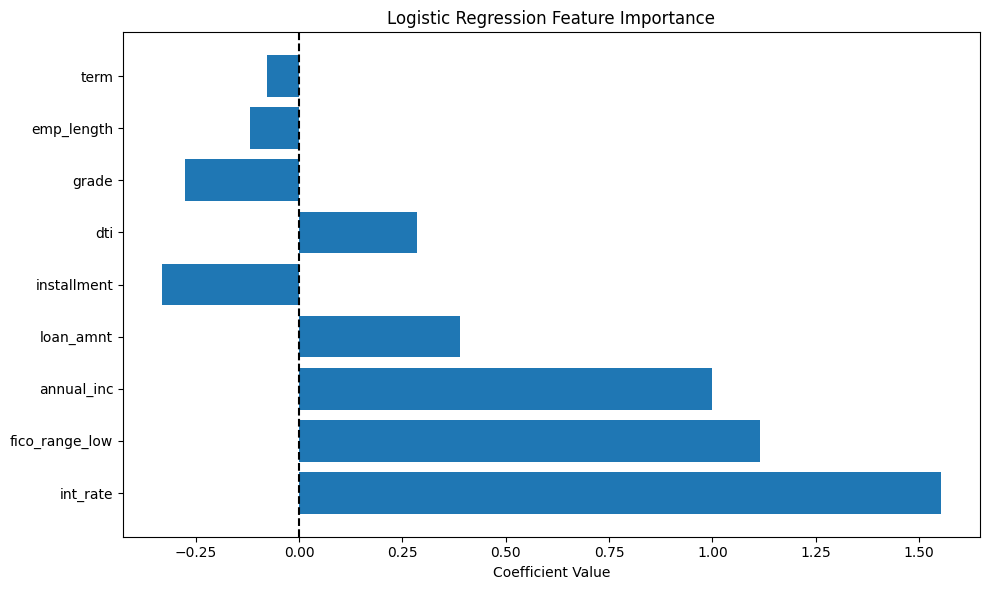


Feature Importance Ranking:
Feature               Coefficient
int_rate                   1.5533
fico_range_low             1.1163
annual_inc                 0.9997
loan_amnt                  0.3899
installment               -0.3319
dti                        0.2853
grade                     -0.2760
emp_length                -0.1192
term                      -0.0767


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract coefficients from the pipeline
lr_model = grid.best_estimator_.named_steps['clf']
feature_names = X.columns

coefficients = lr_model.coef_[0]
sorted_idx = np.argsort(np.abs(coefficients))[::-1]

plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], coefficients[sorted_idx])
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Feature Importance')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Print ranked features
print("\nFeature Importance Ranking:")
print(f"{'Feature':<20} {'Coefficient':>12}")
print("=" * 35)
for i in sorted_idx:
    print(f"{feature_names[i]:<20} {coefficients[i]:>12.4f}")

Key Business Insights:

- int_rate is the strongest predictor : high-risk borrowers get high rates, which confirms the model is learning correctly

- fico_range_low and annual_inc are powerful signals — creditworthiness and income matter most

- term and emp_length contribute the least — consider dropping them in a leaner model